In [ ]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

In [ ]:
housing=fetch_california_housing()
data=fetch_california_housing(as_frame=True).frame

In [ ]:
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
data.shape

(20640, 9)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
print(data.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


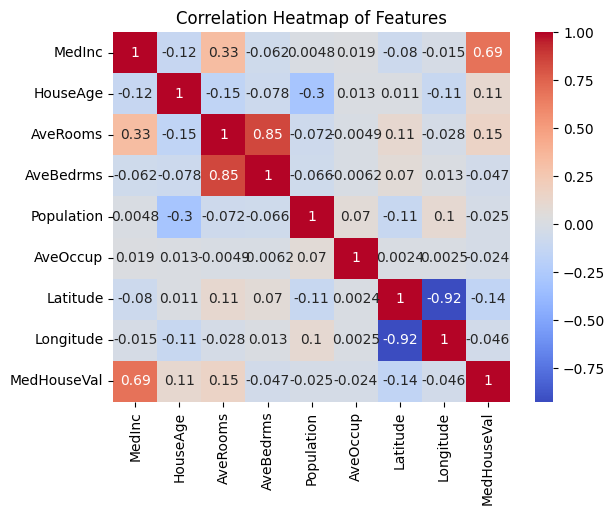

In [ ]:
import matplotlib.pyplot as plt
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

In [ ]:
X = data.drop('MedHouseVal', axis=1)
y = data['MedHouseVal']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(16512, 8)
(4128, 8)


In [ ]:
print(X_train_scaled)

[[-0.326196    0.34849025 -0.17491646 ...  0.05137609 -1.3728112
   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 ... -0.11736222 -0.87669601
   0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 ... -0.03227969 -0.46014647
  -0.44760309]
 ...
 [-0.49697313  0.58654547 -0.60675918 ...  0.02030568 -0.75500738
   0.59946887]
 [ 0.96545045 -1.07984112  0.40217517 ...  0.00707608  0.90651045
  -1.18553953]
 [-0.68544764  1.85617335 -0.85144571 ... -0.08535429  0.99543676
  -1.41489815]]


In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nIntercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("Mean Squared Error:", mse)
print("R² Score:", r2)


Intercept: 2.0719469373788777
Coefficients: [ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]
Mean Squared Error: 0.5558915986952442
R² Score: 0.575787706032451


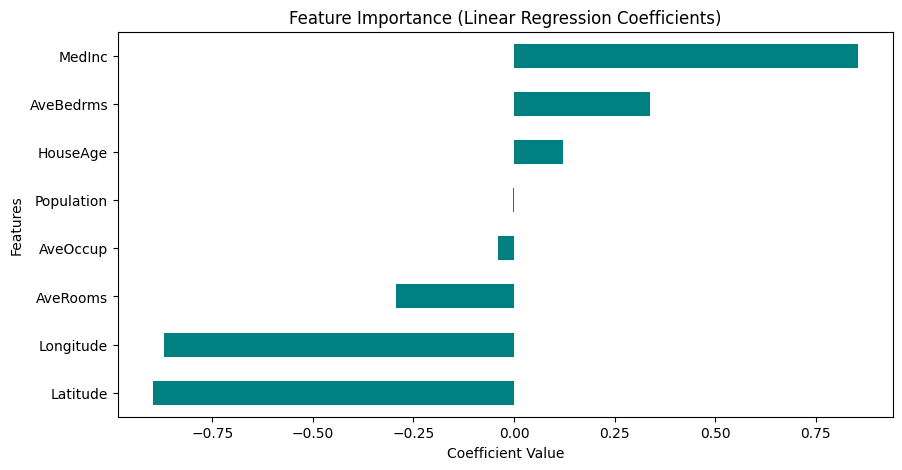

In [ ]:

feature_importance = pd.Series(model.coef_, index=X.columns)
plt.figure(figsize=(10,5))
feature_importance.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()


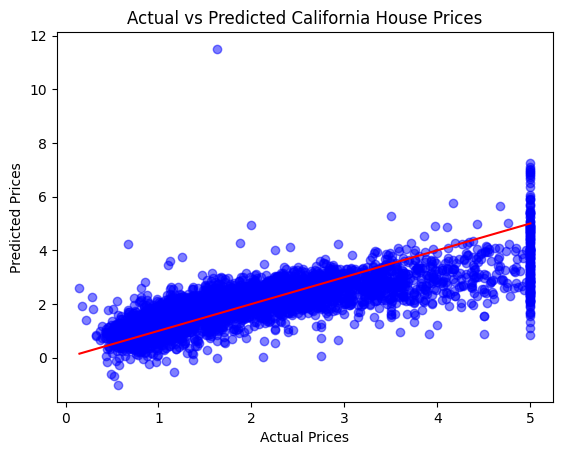

In [ ]:
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted California House Prices')
plt.show()

In [ ]:
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [ ]:
sample_input = np.array([[8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23]])
sample_input_scaled = scaler.transform(sample_input)
predicted_value = model.predict(sample_input_scaled)[0]
print(f"\nPredicted Median House Value: ${predicted_value * 100000:.2f}")


Predicted Median House Value: $415194.31


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**ECOMMERCE DATASET**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
file_path="/content/International sale Report.csv"

In [ ]:
df=pd.read_csv(file_path)

In [ ]:
df

,index,DATE,Months,CUSTOMER,Style,SKU,Size,PCS,RATE,GROSS AMT
0,0,6/5/2021,21-Jun,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-L,L,1,616.56,617
1,1,6/5/2021,21-Jun,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XL,XL,1,616.56,617
2,2,6/5/2021,21-Jun,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XXL,XXL,1,616.56,617
3,3,6/5/2021,21-Jun,REVATHY LOGANATHAN,MEN5009,MEN5009-KR-L,L,1,616.56,617
4,4,6/5/2021,21-Jun,REVATHY LOGANATHAN,MEN5011,MEN5011-KR-L,L,1,616.56,617
...,...,...,...,...,...,...,...,...,...,...
37427,37427,AVIN,3/31/2022,22-Mar,PJNE3423,PJNE3423-KR-4XL,1,537.5,538,4
37428,37428,AVIN,3/31/2022,22-Mar,PJNE3404,PJNE3404-KR-4XL,1,500,500,5
37429,37429,AVIN,3/31/2022,22-Mar,PJNE3423,PJNE3423-KR-4XL,1,537.5,538,4
37430,37430,AVIN,3/31/2022,22-Mar,SET290,SET290-KR-DPT-M,1,812.5,812,7


In [ ]:
df.head()

,index,DATE,Months,CUSTOMER,Style,SKU,Size,PCS,RATE,GROSS AMT
0,0,6/5/2021,21-Jun,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-L,L,1,616.56,617
1,1,6/5/2021,21-Jun,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XL,XL,1,616.56,617
2,2,6/5/2021,21-Jun,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XXL,XXL,1,616.56,617
3,3,6/5/2021,21-Jun,REVATHY LOGANATHAN,MEN5009,MEN5009-KR-L,L,1,616.56,617
4,4,6/5/2021,21-Jun,REVATHY LOGANATHAN,MEN5011,MEN5011-KR-L,L,1,616.56,617


In [ ]:
df.shape


(37432, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37432 entries, 0 to 37431
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   index      37432 non-null  int64 
 1   DATE       37431 non-null  object
 2   Months     37407 non-null  object
 3   CUSTOMER   36392 non-null  object
 4   Style      36392 non-null  object
 5   SKU        34958 non-null  object
 6   Size       36392 non-null  object
 7   PCS        36392 non-null  object
 8   RATE       36392 non-null  object
 9   GROSS AMT  36392 non-null  object
dtypes: int64(1), object(9)
memory usage: 2.9+ MB


In [ ]:
df.describe()

,index
count,37432.000000
mean,18715.500000
std,10805.831975
min,0.000000
25%,9357.750000
50%,18715.500000
75%,28073.250000
max,37431.000000


In [ ]:
df.duplicated().value_counts()

,count
False,37432


In [ ]:
df=df.drop_duplicates()

In [ ]:
df.duplicated().value_counts()

,count
False,37432


In [ ]:
df=df.drop(columns=['CUSTOMER'])

In [ ]:
# Convert 'PCS', 'RATE', 'GROSS AMT' to numeric, coercing errors
df['PCS'] = pd.to_numeric(df['PCS'], errors='coerce')
df['RATE'] = pd.to_numeric(df['RATE'], errors='coerce')
df['GROSS AMT'] = pd.to_numeric(df['GROSS AMT'], errors='coerce')

# Drop rows where 'PCS', 'RATE', or 'GROSS AMT' are NaN after conversion
df.dropna(subset=['PCS', 'RATE', 'GROSS AMT'], inplace=True)

In [ ]:
df

,index,DATE,Months,Style,SKU,Size,PCS,RATE,GROSS AMT
0,0,6/5/2021,21-Jun,MEN5004,MEN5004-KR-L,L,1.0,616.56,617.0
1,1,6/5/2021,21-Jun,MEN5004,MEN5004-KR-XL,XL,1.0,616.56,617.0
2,2,6/5/2021,21-Jun,MEN5004,MEN5004-KR-XXL,XXL,1.0,616.56,617.0
3,3,6/5/2021,21-Jun,MEN5009,MEN5009-KR-L,L,1.0,616.56,617.0
4,4,6/5/2021,21-Jun,MEN5011,MEN5011-KR-L,L,1.0,616.56,617.0
...,...,...,...,...,...,...,...,...,...
37427,37427,AVIN,3/31/2022,PJNE3423,PJNE3423-KR-4XL,1,537.5,538.00,4.0
37428,37428,AVIN,3/31/2022,PJNE3404,PJNE3404-KR-4XL,1,500.0,500.00,5.0
37429,37429,AVIN,3/31/2022,PJNE3423,PJNE3423-KR-4XL,1,537.5,538.00,4.0
37430,37430,AVIN,3/31/2022,SET290,SET290-KR-DPT-M,1,812.5,812.00,7.0


In [ ]:
print(df.isnull().sum())

index           0
DATE            0
Months          0
Style           0
SKU          1434
Size            0
PCS             0
RATE            0
GROSS AMT       0
dtype: int64


In [ ]:
df=df.drop(columns=['SKU'])

In [ ]:
df=df.drop(columns=['Months'])

In [ ]:
df=df.drop(columns=['DATE'])

In [ ]:
df

,index,Style,Size,PCS,RATE,GROSS AMT
0,0,MEN5004,L,1.0,616.56,617.0
1,1,MEN5004,XL,1.0,616.56,617.0
2,2,MEN5004,XXL,1.0,616.56,617.0
3,3,MEN5009,L,1.0,616.56,617.0
4,4,MEN5011,L,1.0,616.56,617.0
...,...,...,...,...,...,...
37427,37427,PJNE3423,1,537.5,538.00,4.0
37428,37428,PJNE3404,1,500.0,500.00,5.0
37429,37429,PJNE3423,1,537.5,538.00,4.0
37430,37430,SET290,1,812.5,812.00,7.0


In [ ]:
df.isnull().sum()

,0
index,0
Style,0
Size,0
PCS,0
RATE,0
GROSS AMT,0


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Style']=le.fit_transform(df['Style'])

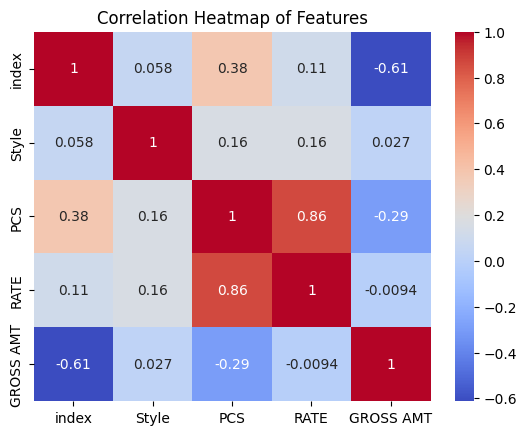

In [ ]:
import matplotlib.pyplot as plt
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

In [ ]:
X = df.drop('GROSS AMT', axis=1)
y = df['GROSS AMT']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(16512, 8)
(4128, 8)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_size = LabelEncoder()
X_train['Size'] = le_size.fit_transform(X_train['Size'])
X_test['Size'] = le_size.transform(X_test['Size'])



In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(X_train_scaled)

[[ 0.28874385  1.68863058  0.11477507 -0.40796678  6.38034892]
 [ 0.59178319  0.76423146 -1.08341774  0.46734094  0.01984388]
 [-0.64484377 -1.67159395  1.22738267 -0.41005085 -0.53527361]
 ...
 [-0.67753075 -0.17703625  0.88504187 -0.41630304 -0.39519724]
 [-1.62928794  1.02063414  0.88504187 -0.41734508  0.03929893]
 [-0.26565654 -0.27150039  0.88504187 -0.41734508 -0.3822272 ]]


In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nIntercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("Mean Squared Error:", mse)
print("R² Score:", r2)


Intercept: 452.815701428964
Coefficients: [-135.10361537   31.15268866  187.68933588 -269.92325902  254.06243382]
Mean Squared Error: 199952.53189068745
R² Score: 0.454169846605638


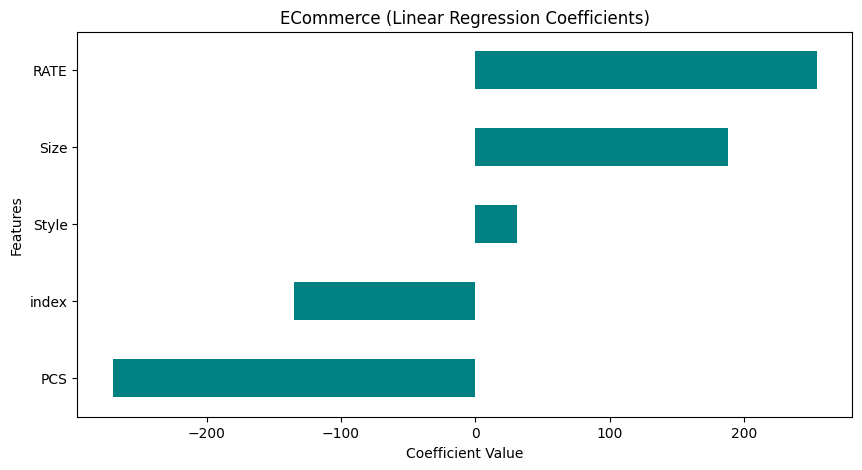

In [ ]:
feature_importance = pd.Series(model.coef_, index=X.columns)
plt.figure(figsize=(10,5))
feature_importance.sort_values().plot(kind='barh', color='teal')
plt.title('ECommerce (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

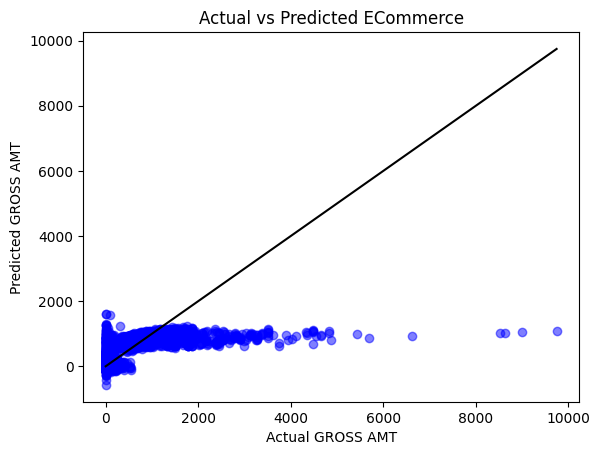

In [ ]:
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black')
plt.xlabel('Actual GROSS AMT')
plt.ylabel('Predicted GROSS AMT')
plt.title('Actual vs Predicted ECommerce')
plt.show()

In [ ]:
df

,index,Style,Size,PCS,RATE,GROSS AMT
0,0,733,L,1.0,616.56,617.0
1,1,733,XL,1.0,616.56,617.0
2,2,733,XXL,1.0,616.56,617.0
3,3,738,L,1.0,616.56,617.0
4,4,740,L,1.0,616.56,617.0
...,...,...,...,...,...,...
37427,37427,795,1,537.5,538.00,4.0
37428,37428,792,1,500.0,500.00,5.0
37429,37429,795,1,537.5,538.00,4.0
37430,37430,946,1,812.5,812.00,7.0


In [ ]:
sample_input = np.array([[98,754,1,8,700]])
sample_input_scaled = scaler.transform(sample_input)
predicted_value = model.predict(sample_input_scaled)[0]
print(f"Ecommerce GROSS AMT: ${predicted_value * 100000:.2f}")

Ecommerce GROSS AMT: $59378368.09


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**Mental Health Dataset**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
file_path="/content/mental health.csv"

In [ ]:
df=pd.read_csv(file_path)